## Day_17_Pandas Advanced — groupby, merge, pivot, dates

Part A — join the tables

TASK 01 Build the master table

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Load the three datasets
# --------------------------------------------------

customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")

# Look at the first few rows of each table
print("CUSTOMERS")
print(customers.head())

print("\nPRODUCTS")
print(products.head())

print("SALES")
print(sales.head())


# --------------------------------------------------
# 2. Identify the shared keys
# --------------------------------------------------

print("\nShared keys : ")
print("Sales -> Customers : customer_id")
print("Sales -> Products : product_id")

print(
    "\nBusiness takeway : Each sale can be connected to a customer using "
    "customer_id and to a product using product_id"
)

# --------------------------------------------------
# 3. Build the master table
# --------------------------------------------------

full = (
    sales
    .merge(customers, on="customer_id", how="left")
    .merge(products, on="product_id", how="left")
)

# Revenue = quantity × unit price
full["revenue"] = full["quantity"] * full["unit_price"]

print("\nMASTER TABLE")
print(full.head())

print(
    "\nBusiness takeway : The Master table combines sales, customer, "
    "and product information so each transaction can be analyzed for revenue."
)


# --------------------------------------------------
# 4. Compare customer join types
# --------------------------------------------------

customer_left = sales.merge(
    customers,
    on="customer_id",
    how="left"
)

customer_inner = sales.merge(
    customers,
    on="customer_id",
    how="inner"
)

customer_outer = sales.merge(
    customers,
    on="customer_id",
    how="outer",
    indicator=True
)

print("\nCUSTOMER JOIN ROW COUNTS")
print("Left Join : ", len(customer_left))
print("Inner Join : ", len(customer_inner))
print("Outer Join : ", len(customer_outer))


# --------------------------------------------------
# 5. Find sales with unknown customers
# --------------------------------------------------

unknown_sales = customer_outer[
    customer_outer["_merge"] == "left_only"
]

print("\nSales with unknown customers : ", len(unknown_sales))
print("Unknown customer IDs:")
print(unknown_sales["customer_id"].unique())

print(
    "\nBusiness takeway : 5 sales use the unknown customer ID C9990, "
    "so these transactions can't be linked to a customer region."
)


# --------------------------------------------------
# 6. Find customers who never ordered
# --------------------------------------------------

never_ordered = customer_outer[
    customer_outer["_merge"] == "right_only"
]

print("\nCustomer who never ordered : ", len(never_ordered))
print("Customer IDs :")
print(never_ordered["customer_id"].tolist())

print(
    "\nBusiness takeaway: 2 customers, C051 and C052, are in the customer "
    "database but have no recorded orders."
)


# --------------------------------------------------
# 7. Revenue calculation
# --------------------------------------------------

print("\nTOTAL REVENUE:", full["revenue"].sum())

print(
    "\nBusiness takeaway: The recorded sales generate total revenue of "
    "405,150 based on quantity multiplied by unit price."
)


# --------------------------------------------------
# 8. Final mismatch summary
# --------------------------------------------------

print("\nMISMATCH SUMMARY")
print("Total sales rows:", len(sales))
print("Matched customer sales:", len(customer_inner))
print("Sales with unknown customers:", len(unknown_sales))
print("Customers who never ordered:", len(never_ordered))

print(
    "\nBusiness takeaway: There are 5 sales with missing customer matches "
    "and 2 customers with no orders."
)

CUSTOMERS
  customer_id customer_name region  signup_year
0        C001    Customer_1  North         2024
1        C002    Customer_2   West         2021
2        C003    Customer_3   East         2022
3        C004    Customer_4  South         2022
4        C005    Customer_5  South         2022

PRODUCTS
  product_id product_name     category  unit_price
0       P001       Laptop  Electronics         800
1       P002        Mouse  Electronics          25
2       P003     Keyboard  Electronics          45
3       P004      Monitor  Electronics         250
4       P005       Webcam  Electronics          60
SALES
  order_id        date customer_id product_id  quantity
0   O00001  31-10-2024        C999       P019         2
1   O00002  14-03-2024        C999       P014         1
2   O00003  21-10-2024        C999       P004         1
3   O00004  03-01-2024        C999       P003         3
4   O00005  18-10-2024        C999       P018         4

Shared keys : 
Sales -> Customers : custome

JOIN DECISION

-> I used a LEFT JOIN for the customer merge because every sale should remain in the revenue report, even when its customer record is missing.

-> An INNER JOIN would remove the 5 sales linked to C999 and could understate the reported revenue

### Research Questions

* **Danger of an inner join:** An inner join keeps only matching records, so the **5 sales linked to unknown customer C999** would silently disappear from the analysis.
* **Finding failed customer lookups:** Check for missing region values using `full[full['region'].isna()]`. These rows show sales where the customer lookup failed.
* **When to use an outer join:** Use an outer join when you need to see **all records from both tables**, including unmatched sales and customers who never ordered. Here, it reveals **5 unmatched sales and 2 customers with no orders**.


Part B — per-region, per-month revenue (the deliverable core)

TASK 02 Revenue breakdowns with groupby

In [22]:
import pandas as pd
import numpy as np

customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")

# Merge orders with customer information to get the region
full = sales.merge(
    customers,
    on="customer_id",
    how="left"
)

# Merge with product information to get category and unit price
full = full.merge(
    products,
    on="product_id",
    how="left"
)


# Convert date column into datetime format
full["date"] = pd.to_datetime(full["date"], dayfirst=True)

# Calculate revenue for each order
# Revenue = Quantity × Unit Price
full["revenue"] = full["quantity"] * full["unit_price"]


# ---------------------------------------------------------
# 1. Total revenue per region and rank the regions
# ---------------------------------------------------------

region_revenue = (
    full.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("1. Total Revenue By Region : ")
print(region_revenue)

print("\nRegion Ranking")
print(region_revenue.rank(method="min", ascending=False).astype(int))


# ---------------------------------------------------------
# 2. Total revenue per product category
# ---------------------------------------------------------

category_revenue = (
    full.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("\n2. Total Revenue by Product CAtegory : ")
print(category_revenue)

# Find the category with the highest total revenue
top_category = category_revenue.idxmax()

print(
    f"\nTHe category that drives the most revenue is "
    f"{top_category}."
)


# ---------------------------------------------------------
# 3. Total revenue, average order revenue,
#    and number of orders per category
# ---------------------------------------------------------

category_summary = (
    full.groupby("category").agg(
        total_revenue=("revenue", "sum"),
        avg_order_revenue=("revenue", "mean"),
        orders=("order_id", "count")
    ).sort_values("total_revenue", ascending=False)
)

print("\n3. Revenue Summary by Category : ")
print(category_summary)


# ---------------------------------------------------------
# 4. Revenue per region per month
# ---------------------------------------------------------

# Extract year and month from the date.
# Using Period('M') keeps different years separate.

full["month"] = full["date"].dt.to_period("M")

region_month_revenue = (
    full.groupby(["region", "month"])["revenue"]
    .sum()
    .sort_index()
)

print("\n4. REvenue per Region per months : ")
print(region_month_revenue)


# ---------------------------------------------------------
# 5. Best and worst month for one region
# ---------------------------------------------------------

# Choose North region for the analysis
chosen_region = "North"

# Get monthly revenue for North
north_monthly = region_month_revenue.loc[chosen_region]

# Find the best and worst months.
best_month = north_monthly.idxmax()
best_revenue = north_monthly.max()

worst_month = north_monthly.idxmin()
worst_revenue = north_monthly.min()

print(f"\n5. Best and Worst Month for {chosen_region} : ")

print(
    f"Best month: {best_month} "
    f"with revenue of {best_revenue:,.2f}"
)

print(
    f"Worst month: {worst_month} "
    f"with revenue of {worst_revenue:,.2f}"
)

1. Total Revenue By Region : 
region
East     121636
West     117271
North     83444
South     81814
Name: revenue, dtype: int64

Region Ranking
region
East     1
West     2
North    3
South    4
Name: revenue, dtype: int64

2. Total Revenue by Product CAtegory : 
category
Electronics    285690
Office         104000
Accessories     12081
Stationery       3379
Name: revenue, dtype: int64

THe category that drives the most revenue is Electronics.

3. Revenue Summary by Category : 
             total_revenue  avg_order_revenue  orders
category                                             
Electronics         285690         466.813725     612
Office              104000         641.975309     162
Accessories          12081          92.930769     130
Stationery            3379          35.197917      96

4. REvenue per Region per months : 
region  month  
East    2024-01    11506
        2024-02    11110
        2024-03    13911
        2024-04    10275
        2024-05     5976
        2024-0

### Short and meaningful answers

**1. Total revenue vs. average order value:**
Total revenue matters when measuring overall business income. Average order value matters when understanding how much customers spend per order.

**2. High total revenue but low average revenue:**
It suggests the category has many orders, but customers spend a relatively small amount on each order.

**3. Grouping by two columns:**
Grouping by two columns shows the relationship between them, such as **revenue for each region in each month**, which gives more detailed insights than separate groupbys.

**Done when:** Revenue is ranked by region and category, category metrics are calculated using `.agg()`, and revenue is broken down by region and month.


TASK 03 Build a pivot table and a crosstab

In [ ]:
import pandas as pd
import numpy as np

customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")

# 1. Pivot table: Revenue by Region and Category
# Rows = Region, Columns = Category, Values = Total Revenue
region_category_pivot = full.pivot_table(
    values = "revenue",
    index="region",
    columns="category",
    aggfunc="sum",
    fill_value=0
)

print("1. Revenue by Region and Category:")
print(region_category_pivot)


# 2. Pivot table: Revenue by Region and Month
# Create a month column from the date

full["months"] = full["date"].dt.to_period("M")

region_months_pivot = full.pivot_table(
    values="revenue",
    index="region",
    columns="month",
    aggfunc="sum",
    fill_value=0
)

print("\n2. Revenue by Region and Month:")
print(region_months_pivot)


# 3. Crosstab: Number of Orders by Region and Category
# Crosstab counts how many orders exist instead of adding revenue

region_category_orders = pd.crosstab(
    full["region"],
    full["category"]
)

print("\n3. Number of Orders By Region and Category : ")
print(region_category_orders)

# Difference:
# The revenue pivot shows MONEY generated,
# while the crosstab shows the NUMBER OF ORDERS.


# 4. Find the region-month combination with the highest revenue
highest_region_month = region_months_pivot.stack().idxmax()
highest_revenue = region_months_pivot.stack().max()

print("\n4. Highest Revenue Region-months Combination :")
print(
    f"Region : {highest_region_month[0]}, "
    f"Month : {highest_region_month[1]}, "
    f"Revenue : {highest_revenue :,.2f}"
)



# 5. Add row and column totals using margins=True
region_category_totals = full.pivot_table(
    values="revenue",
    index="region",
    columns="category",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="Total"
)
 
print("\n5. Revenue Pivot with Row and Column Totals : ")
print(region_category_totals)


1. Revenue by Region and Category:
category  Accessories  Electronics  Office  Stationery
region                                                
East             3379        86260   31020         977
North            2231        56815   23420         978
South            3341        55530   22440         503
West             3110        86120   27120         921

2. Revenue by Region and Month:
month   2024-01  2024-02  2024-03  2024-04  2024-05  2024-06  2024-07  \
region                                                                  
East      11506    11110    13911    10275     5976     6378     9568   
North      2975    12119     7269     8534    11601     6915     5573   
South      6114    12525    10415     3930     6320     3685     5078   
West      11831    12241     6993     5963     3394    14742    14303   

month   2024-08  2024-09  2024-10  2024-11  2024-12  
region                                               
East      12035    12640     8635     5029    14573  
N

### Short and meaningful answers

1. **When do you use `pivot_table` vs `crosstab`?**
   Use `pivot_table` when you need **aggregated values** such as revenue or average. Use `crosstab` mainly for **counting frequencies** between categories. 

2. **What does `fill_value=0` do?**
   It replaces missing cells in the pivot table with **0**. This is useful when a missing combination means **no revenue or no activity**, rather than unknown data.

3. **Could you make the same grid with `groupby`? What does pivot give you that's nicer?**
   Yes. `groupby` can produce the same summary, but `pivot_table` presents the results as a **readable row-and-column grid**, making comparisons easier. 

**Done when:** Region-by-category revenue pivot, region-by-month revenue pivot, order-count crosstab, and the highest-revenue region-month are identified.




Part C — unlock the dates

TASK 04 Day-of-week effects and monthly trends

C:\Users\MIHIR SOLANKI\AppData\Local\Temp\ipykernel_40156\2009972655.py:18: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  full["date"] = pd.to_datetime(full["date"])


1. Date Information
        date  month   day_name  quarter
0 2024-10-31     10   Thursday        4
1 2024-03-14      3   Thursday        1
2 2024-10-21     10     Monday        4
3 2024-01-03      1  Wednesday        1
4 2024-10-18     10     Friday        4

2. Revenue by Day of the week :
day_name
Monday       51266
Tuesday      61293
Wednesday    43207
Thursday     67003
Friday       56667
Saturday     50325
Sunday       75389
Name: revenue, dtype: int64

Business day : Sunday

3. Monthly Revenue
date
2024-01-31    32561
2024-02-29    47995
2024-03-31    38608
2024-04-30    28702
2024-05-31    27291
2024-06-30    31720
2024-07-31    34522
2024-08-31    31247
2024-09-30    29860
2024-10-31    30620
2024-11-30    33303
2024-12-31    38721
Freq: ME, Name: revenue, dtype: int64

4. Weekly Revenue
date
2024-01-07    10707
2024-01-14    13783
2024-01-21     4246
2024-01-28     2010
2024-02-04    16042
2024-02-11     7075
2024-02-18     8341
2024-02-25    11364
2024-03-03     9165
2024-03

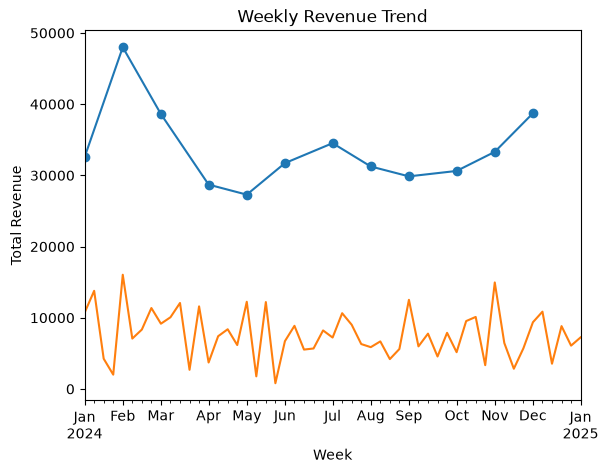

In [3]:
import pandas as pd
import numpy as np

customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")

# Merge sales with customer information
full = sales.merge(customers, on="customer_id", how="left")

# Merge sales with product information
full = full.merge(products, on="product_id", how="left")

# Calculate revenue
full["revenue"] = full["quantity"] * full["unit_price"]

# 1. Convert the date column into datetime format
full["date"] = pd.to_datetime(full["date"])

# 2. Extract month, day name, and quarter
full["month"] = full["date"].dt.month
full["day_name"] = full["date"].dt.day_name()
full["quarter"] = full["date"].dt.quarter

print("1. Date Information") 
print(full[["date", "month", "day_name", "quarter"]].head())

# 3. Revenue by day of the week
# Use categorical ordering so days appear Monday to Sunday
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]

day_revenue = (
    full.groupby("day_name")["revenue"].sum().reindex(day_order)    
)

print("\n2. Revenue by Day of the week :")
print(day_revenue)

busiest_day = day_revenue.idxmax()
print(f"\nBusiness day : {busiest_day}")

# 4. Monthly total revenue
# Set date as the index because resample() works with datetime indexes
monthly_revenue = (
    full.set_index("date").resample("ME")["revenue"].sum()
)

print("\n3. Monthly Revenue")
print(monthly_revenue)

# Plot monthly revenue trend
monthly_revenue.plot(
    kind="line",
    marker="o",
    title="Monthly Revenue Trend",
    xlabel="Month",
    ylabel="Toatal Revenue"
)


# 5. Weekly total revenue

weekly_revenue = (
    full.set_index("date").resample("W")["revenue"].sum()
)

print("\n4. Weekly Revenue")
print(weekly_revenue)

# Plot weekly revenue
weekly_revenue.plot(
    kind="line",
    title="Weekly Revenue Trend",
    xlabel="Week",
    ylabel="Total Revenue"
)

# 6. Find the peak month
peak_month = monthly_revenue.idxmax()
peak_revenue = monthly_revenue.max()

print(
    f"\nPeak MOnth : {peak_month.strftime("%B %Y")} "
    f"with revenue of {peak_revenue:,.2f}"
)


### Short and meaningful answers

1. **Why parse dates first?**
   Date parsing converts text into real datetime values, allowing Pandas to correctly extract the day, month, quarter, and other date features. 

2. **Resampling vs. grouping by month:**
   A month column groups all Januarys together, even across different years. `resample()` keeps the **year and month as separate time periods**, making it better for time-series trends. 

3. **How can day-of-week effects help business decisions?**
   If certain days consistently have higher demand, a business can schedule more staff or run promotions on those days and reduce resources during quieter periods. 

**Done when:** Dates are parsed and features extracted, weekday revenue is ordered Monday–Sunday, monthly revenue is plotted, and weekly results are compared for trend vs. noise.




TASK 05 String operations

In [ ]:
import pandas as pd
import numpy as np

# Use Pandas string methods (.str) to search, clean, and transform text data.

# Load the CSV files
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")

# ---------------------------------------------------------
# 1. Find products whose name contains a particular letter
# ---------------------------------------------------------
# case=False makes the search case-insensitive.
# na=False prevents missing product names from causing errors.

products_with_a = products[
    products["product_name"].str.contains("a", case=False, na=False)
]

print("1. Products containing the latter 'a' : ")
print(products_with_a[["product_id", "product_name"]])

# ---------------------------------------------------------
# 2. Create category in uppercase
# ---------------------------------------------------------
# .str.upper() converts all category names to uppercase.

products["category_upper"] = products["category"].str.upper()

print("\n2. Categories in uppercase : ")
print(products[["product_name", "category", "category_upper"]].head())


# ---------------------------------------------------------
# 3. Create a column for product-name length
# ---------------------------------------------------------

# .str.len() counts the number of characters in each product name.

products["product_name_length"] = products["product_name"].str.len()

print("\n3. Product name Lengths")
print(products[["product_name", "product_name_length"]].head())


# ---------------------------------------------------------
# 4. Count customer IDs ending in a particular digit
# ---------------------------------------------------------

# Here, we count customer IDs ending with the digit '5'.
# Change "5" to another digit if required.

customer_ids_ending_5 = customers[
    customers["customer_id"].astype(str).str.endswith("5", na=False)
]

print("\n4. Customers whose ID ends with '5' : ")
print(len(customer_ids_ending_5))

# ---------------------------------------------------------
# 5. Clean text columns
# ---------------------------------------------------------

# .str.strip() removes extra spaces.
# .str.title() gives consistent title-case formatting.

customers["customer_name_clean"] = (
    customers["customer_name"].str.strip().str.title()
)

products["products_name_clean"] = (
    products["product_name"].str.strip().str.title()
)

products["category_clean"] = (
    products["category"].str.strip().str.title()
)

print("\n Cleaned text columns : ")
print(
    products[
        ["product_name", "products_name_clean", "category", "category_clean"]
    ].head()
)



1. Products containing the latter 'a' : 
   product_id   product_name
0        P001         Laptop
2        P003       Keyboard
4        P005         Webcam
5        P006     Headphones
7        P008      Desk Lamp
8        P009          Chair
9        P010  Standing Desk
12       P013       Backpack
13       P014   Water Bottle
14       P015    Phone Stand
15       P016      Cable Set
16       P017     Power Bank
17       P018        Speaker
19       P020         Tablet

2. Categories in uppercase : 
  product_name     category category_upper
0       Laptop  Electronics    ELECTRONICS
1        Mouse  Electronics    ELECTRONICS
2     Keyboard  Electronics    ELECTRONICS
3      Monitor  Electronics    ELECTRONICS
4       Webcam  Electronics    ELECTRONICS

3. Product name Lengths
  product_name  product_name_length
0       Laptop                    6
1        Mouse                    5
2     Keyboard                    8
3      Monitor                    7
4       Webcam                

### Short and meaningful answers

1. **Why are vectorised `.str` operations better than looping?**
   They apply operations to the whole Series efficiently, avoiding slow Python-level row-by-row loops. Pandas recommends vectorized operations for better performance.

2. **What does `case=False` do in `.str.contains()`?**
   It makes the search **case-insensitive**, so `"a"` matches both `"a"` and `"A"`. Use it when capitalization should not affect the search. 

3. **Where does messy text data come from, and why clean it?**
   It commonly comes from different data-entry methods, imported systems, or inconsistent formatting, causing extra spaces, different capitalization, missing values, and other inconsistencies. Cleaning makes the data more consistent and reliable for analysis. 

**Done when:** Products are filtered by a name pattern, string-based columns are created, and at least one text-cleaning operation such as `.str.strip()` or `.str.lower()` is demonstrated.


